In [1]:
# ============================================
# Startup Cell: Mount Drive + Prepare Data
# ============================================

from google.colab import drive
drive.mount("/content/drive")

import os
import shutil

BASE_DRIVE_DIR = "/content/drive/MyDrive/DIP_Project"
CONTENT_DIR = "/content"
IMG_DIR = f"{CONTENT_DIR}/images"
ZIP_PATH = f"{BASE_DRIVE_DIR}/images.zip"

INPUT_FILES = [
    "train_metadata.csv",
    "validation_metadata.csv",
    "test_metadata.csv",
]

# --------------------------------------------
# Copy metadata CSVs to /content
# --------------------------------------------

print("Copying metadata CSV files...")

for filename in INPUT_FILES:
    src = os.path.join(BASE_DRIVE_DIR, filename)
    dst = os.path.join(CONTENT_DIR, filename)

    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing source file: {src}")

    shutil.copy(src, dst)
    print(f"Copied: {filename}")

print("\nMetadata CSVs copied.")

# --------------------------------------------
# Unzip images if needed
# --------------------------------------------

if not os.path.exists(IMG_DIR):
    print("Creating images directory and unzipping...")
    os.makedirs(IMG_DIR, exist_ok=True)

    local_zip = os.path.join(CONTENT_DIR, "images.zip")
    shutil.copy(ZIP_PATH, local_zip)

    !unzip -q "/content/images.zip" -d "/content/"

    files_in_root = [
        f for f in os.listdir("/content")
        if f.endswith((".png", ".jpg", ".jpeg"))
    ]

    if len(files_in_root) > 0:
        print("Fixing structure: moving images into /content/images/")
        for f in files_in_root:
            shutil.move(f"/content/{f}", f"{IMG_DIR}/{f}")
else:
    print("Images already present.")

# --------------------------------------------
# Verification
# --------------------------------------------

print("\nVerification:")
print("Images:", len(os.listdir(IMG_DIR)))
for filename in INPUT_FILES:
    print(f"{filename} exists:", os.path.exists(os.path.join(CONTENT_DIR, filename)))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying metadata CSV files...
Copied: train_metadata.csv
Copied: validation_metadata.csv
Copied: test_metadata.csv

Metadata CSVs copied.
Images already present.

Verification:
Images: 12000
train_metadata.csv exists: True
validation_metadata.csv exists: True
test_metadata.csv exists: True


In [2]:
# ============================================
# Cell 0: Notebook Overview
# ============================================
# Purpose:
#   This notebook explores and verifies spatial feature
#   extraction using a selected split of the preprocessed image
#   dataset.
#
# Inputs:
#   The notebook expects:
#     - split-specific metadata CSV file:
#         /content/train_metadata.csv
#         /content/validation_metadata.csv
#         /content/test_metadata.csv
#     - shared preprocessed image directory containing all 12000 images:
#         /content/images/
#
# Assumptions:
#   - The shared image directory contains all 12000 preprocessed images.
#   - The selected metadata CSV identifies which images belong to the
#     chosen dataset split.
#   - All images have already been preprocessed.
#   - All images are already grayscale.
#   - All images have already been resized to 256 x 256.
#   - This notebook does NOT perform resizing or grayscale conversion.
#   - This notebook focuses only on spatial feature extraction.
#   - Class labels are taken from metadata, not inferred from filenames.
#   - Expected split sizes are:
#       - train: 8400 images
#       - validation: 1800 images
#       - test: 1800 images
#
# What the notebook does:
#   Cell 1:
#     Import required libraries for image loading, numerical processing,
#     spatial analysis, feature extraction, and visualization.
#
#   Cell 2:
#     Define the selected split, input paths, output path, and sample
#     image placeholders for exploratory analysis.
#
#   Cell 3:
#     Verify required inputs exist before processing:
#       - confirm the selected metadata CSV exists
#       - confirm /content/images/ directory exists
#       - confirm image files are present
#       - confirm metadata has expected columns and expected row count
#         for the selected split
#       - select the first image listed in the metadata CSV as the
#         sample image
#       - confirm sample image filenames match actual files
#
#   Cell 4:
#     Load the selected preprocessed image and verify its properties,
#     including:
#       - shape
#       - datatype
#       - intensity range
#
#   Cell 5:
#     Define helper functions for spatial feature computation,
#     including:
#       - global entropy
#       - local entropy statistics
#       - intensity statistics
#       - Laplacian variance
#       - patch variance statistics
#       - noise residual energy
#       - full spatial feature extraction
#
#   Cell 6:
#     Compute intermediate spatial representations for the sample image
#     and generate the corresponding spatial feature values.
#
#   Cell 7:
#     Display intermediate visual results for the sample image, such as:
#       - input image
#       - local entropy map
#       - Laplacian response
#       - noise residual image
#
#   Cell 8:
#     Plot histograms or profiles related to:
#       - pixel intensity values
#       - local entropy values
#       - residual or patch-variance-related values
#
#   Cell 9:
#     Compute and print these 9 spatial features for the sample image:
#       - Global Entropy
#       - Local Entropy Mean
#       - Local Entropy Std
#       - Intensity Mean
#       - Intensity Std
#       - Laplacian Variance
#       - Patch Variance Mean
#       - Patch Variance Std
#       - Noise Residual Energy
#
#   Cell 10:
#     Repeat the same analysis on a small set of additional images from
#     the selected split to compare real and AI-generated examples.
#
#   Cell 11:
#     Apply spatial feature extraction to all images identified by the
#     selected metadata CSV and save the results to a split-specific
#     output file:
#       /content/train_spatial_features.csv
#       /content/validation_spatial_features.csv
#       /content/test_spatial_features.csv
#
# Outputs:
#   Primary output:
#     - visual validation of spatial feature extraction behavior
#     - printed spatial feature values for selected images
#
#   Optional CSV output:
#     - /content/train_spatial_features.csv
#     - /content/validation_spatial_features.csv
#     - /content/test_spatial_features.csv
#
# Notes:
#   - This is an exploratory notebook intended to verify correctness
#     before scaling to full dataset feature extraction.
#   - Only images listed in the selected metadata CSV are used for
#     feature extraction, even though /content/images/ contains all
#     12000 preprocessed images.
#   - Only spatial features are extracted in this notebook.
#   - Later work can combine gradient, spatial, and frequency-domain
#     features into a single dataset for classifier training and
#     evaluation.
#   - The same notebook structure and functionality are preserved while
#     allowing selection of the train, validation, or test split.
# ============================================

print("Notebook overview loaded.")



Notebook overview loaded.


In [3]:
# ============================================
# Cell 1: Imports
# ============================================

import os

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt

from scipy.stats import entropy

from skimage.filters.rank import entropy as sk_entropy
from skimage.morphology import footprint_rectangle

print("Libraries imported successfully.")



Libraries imported successfully.


In [4]:
# ============================================
# Cell 2: Define Input Paths and Sample Image
# ============================================

import os

# -------------------------------------------------
# Select dataset split
# -------------------------------------------------
SPLIT_NAME = "train"   # options: "train", "validation", "test"

# -------------------------------------------------
# Define paths
# -------------------------------------------------
METADATA_CSV = f"/content/{SPLIT_NAME}_metadata.csv"
IMG_DIR = "/content/images"

# Output CSV (for full dataset extraction)
OUTPUT_CSV = f"/content/{SPLIT_NAME}_spatial_features.csv"

# -------------------------------------------------
# Expected row counts (for validation in Cell 3)
# -------------------------------------------------
EXPECTED_ROWS = {
    "train": 8400,
    "validation": 1800,
    "test": 1800
}

# -------------------------------------------------
# Sample image (set in Cell 3 after loading metadata)
# -------------------------------------------------
SAMPLE_FILENAME = None
SAMPLE_IMAGE_PATH = None

# -------------------------------------------------
# Display configuration
# -------------------------------------------------
print("SPLIT_NAME      =", SPLIT_NAME)
print("METADATA_CSV    =", METADATA_CSV)
print("IMG_DIR         =", IMG_DIR)
print("OUTPUT_CSV      =", OUTPUT_CSV)
print("EXPECTED_ROWS   =", EXPECTED_ROWS[SPLIT_NAME])
print("SAMPLE_IMAGE    =", SAMPLE_IMAGE_PATH)


SPLIT_NAME      = train
METADATA_CSV    = /content/train_metadata.csv
IMG_DIR         = /content/images
OUTPUT_CSV      = /content/train_spatial_features.csv
EXPECTED_ROWS   = 8400
SAMPLE_IMAGE    = None


In [5]:
# ============================================
# Cell 3: Input Validation
# ============================================

# --- Check metadata CSV ---
assert os.path.exists(METADATA_CSV), f"Missing file: {METADATA_CSV}"
print(f"PASS: Found metadata CSV -> {METADATA_CSV}")

# --- Check shared image directory ---
assert os.path.isdir(IMG_DIR), f"Missing directory: {IMG_DIR}"
print(f"PASS: Found image directory -> {IMG_DIR}")

# --- Check image files exist in shared directory ---
image_files = os.listdir(IMG_DIR)
assert len(image_files) > 0, "No images found in shared image directory"
print(f"PASS: Found {len(image_files)} files in image directory")

# --- Load selected-split metadata ---
df = pd.read_csv(METADATA_CSV)
print(f"PASS: Loaded metadata CSV with shape {df.shape}")

# --- Check expected row count ---
assert df.shape[0] == EXPECTED_ROWS[SPLIT_NAME], (
    f"Expected {EXPECTED_ROWS[SPLIT_NAME]} rows for {SPLIT_NAME}, "
    f"found {df.shape[0]}"
)
print(f"PASS: Metadata contains expected {EXPECTED_ROWS[SPLIT_NAME]} {SPLIT_NAME} rows")

# --- Check required columns ---
required_cols = ["filename", "class_label", "source_dataset"]
for col in required_cols:
    assert col in df.columns, f"Missing required column: {col}"
print("PASS: Required columns present")


# --- Check subset column matches selected split ---
assert "subset" in df.columns, "Missing required column: subset"
unique_subsets = sorted(df["subset"].dropna().unique().tolist())
assert unique_subsets == [SPLIT_NAME], (
    f"Expected subset column to contain only {SPLIT_NAME}, "
    f"found {unique_subsets}"
)
print(f"PASS: subset column matches SPLIT_NAME -> {SPLIT_NAME}")


# --- Select sample image (first row of metadata) ---
SAMPLE_FILENAME = df["filename"].iloc[0]
SAMPLE_IMAGE_PATH = os.path.join(IMG_DIR, SAMPLE_FILENAME)

assert os.path.exists(SAMPLE_IMAGE_PATH), f"Sample image not found: {SAMPLE_FILENAME}"
print(f"PASS: Sample image selected -> {SAMPLE_FILENAME}")

# --- Check a few metadata filenames exist in shared image directory ---
missing_files = []
for fname in df["filename"].head(10):
    fpath = os.path.join(IMG_DIR, fname)
    if not os.path.exists(fpath):
        missing_files.append(fname)

assert len(missing_files) == 0, f"Missing image files: {missing_files}"
print(f"PASS: Sample {SPLIT_NAME} metadata image files exist")

print("\nAll input validation checks passed.")



PASS: Found metadata CSV -> /content/train_metadata.csv
PASS: Found image directory -> /content/images
PASS: Found 12000 files in image directory
PASS: Loaded metadata CSV with shape (8400, 5)
PASS: Metadata contains expected 8400 train rows
PASS: Required columns present
PASS: subset column matches SPLIT_NAME -> train
PASS: Sample image selected -> ai_diff_002852.png
PASS: Sample train metadata image files exist

All input validation checks passed.


Inspecting sample image from train split: ai_diff_002852.png
Shape: (256, 256)
Dtype: float32
Min: 0.0
Max: 0.9882352948188782
Mean: 0.4581524133682251
Std: 0.2544228136539459


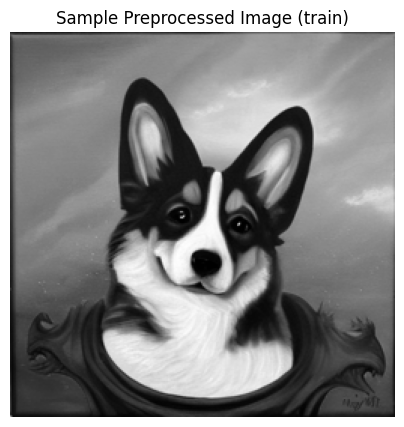

In [6]:
# ============================================
# Cell 4: Load and Inspect Sample Image
# ============================================

def load_preprocessed_image(image_path):
    img = Image.open(image_path)
    img = np.array(img)

    if img.ndim == 3 and img.shape[2] == 1:
        img = img[:, :, 0]
    elif img.ndim != 2:
        raise ValueError(f"Expected grayscale image, got shape {img.shape}")

    img = img.astype(np.float32)

    if img.max() > 1.0:
        img = img / 255.0

    return img


def inspect_image(img):
    print("Shape:", img.shape)
    print("Dtype:", img.dtype)
    print("Min:", float(img.min()))
    print("Max:", float(img.max()))
    print("Mean:", float(img.mean()))
    print("Std:", float(img.std()))


# Load sample image selected in Cell 3
img = load_preprocessed_image(SAMPLE_IMAGE_PATH)

print(f"Inspecting sample image from {SPLIT_NAME} split: {SAMPLE_FILENAME}")
inspect_image(img)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Sample Preprocessed Image ({SPLIT_NAME})")
plt.axis("off")
plt.show()



In [7]:
# ============================================
# Cell 5: Spatial Feature Helper Functions
# ============================================

def safe_entropy_from_hist(hist, eps=1e-12):
    hist = hist.astype(np.float64)
    hist = hist / (hist.sum() + eps)
    hist = np.clip(hist, eps, None)
    return float(entropy(hist, base=2))


def image_hist_entropy(img, bins=256):
    hist, _ = np.histogram(img.ravel(), bins=bins, range=(0.0, 1.0))
    return safe_entropy_from_hist(hist)


def compute_local_entropy(img, window_size=9):
    """
    Compute local entropy using the same 32-level quantization idea as the
    original loop-based version, but with an optimized scikit-image
    implementation for efficiency.

    Notes:
      - Input image remains at full 256x256 resolution.
      - The image is converted to uint8 because rank-based entropy expects
        integer-valued grayscale input.
      - This approach is much faster than explicit Python nested loops
        because the neighborhood entropy computation is performed by
        compiled library code rather than Python-level iteration.
    """
    img_uint8 = (img * 255).astype(np.uint8)
    img_q = (img_uint8 // 8).astype(np.uint8)  # 32 quantization levels: 0..31

    local_entropy = sk_entropy(
        img_q,
        footprint_rectangle((window_size, window_size))
    ).astype(np.float32)

    return local_entropy


def compute_laplacian(img):
    return cv2.Laplacian(img, cv2.CV_32F)


def patch_variance_stats(img, patch_size=16):
    h, w = img.shape
    h_crop = (h // patch_size) * patch_size
    w_crop = (w // patch_size) * patch_size

    img_c = img[:h_crop, :w_crop]

    patches = img_c.reshape(
        h_crop // patch_size, patch_size,
        w_crop // patch_size, patch_size
    ).transpose(0, 2, 1, 3)

    patch_vars = patches.reshape(-1, patch_size, patch_size).var(axis=(1, 2))

    return float(patch_vars.mean()), float(patch_vars.std())


def compute_noise_residual(img):
    blurred = cv2.GaussianBlur(img, (5, 5), 0)
    residual = img - blurred
    return residual


def extract_spatial_features(img):
    global_entropy = image_hist_entropy(img)

    local_entropy_map = compute_local_entropy(img)
    local_entropy_mean = float(np.mean(local_entropy_map))
    local_entropy_std = float(np.std(local_entropy_map))

    intensity_mean = float(np.mean(img))
    intensity_std = float(np.std(img))

    lap = compute_laplacian(img)
    lap_var = float(np.var(lap))

    patch_mean, patch_std = patch_variance_stats(img)

    residual = compute_noise_residual(img)
    residual_energy = float(np.mean(residual ** 2))

    features = {
        "Global Entropy": global_entropy,
        "Local Entropy Mean": local_entropy_mean,
        "Local Entropy Std": local_entropy_std,
        "Intensity Mean": intensity_mean,
        "Intensity Std": intensity_std,
        "Laplacian Variance": lap_var,
        "Patch Variance Mean": patch_mean,
        "Patch Variance Std": patch_std,
        "Noise Residual Energy": residual_energy,
    }

    return features, local_entropy_map, lap, residual


print("Spatial helper functions defined.")



Spatial helper functions defined.


In [8]:
# ============================================
# Cell 6: Compute Spatial Components
# ============================================

features, local_entropy_map, lap, residual = extract_spatial_features(img)

patch_var_mean, patch_var_std = patch_variance_stats(img)

print(f"Spatial components computed successfully for {SPLIT_NAME} sample image.")
print("Local entropy map shape =", local_entropy_map.shape)
print("Laplacian shape         =", lap.shape)
print("Residual shape          =", residual.shape)
print("Patch variance mean     =", patch_var_mean)
print("Patch variance std      =", patch_var_std)



Spatial components computed successfully for train sample image.
Local entropy map shape = (256, 256)
Laplacian shape         = (256, 256)
Residual shape          = (256, 256)
Patch variance mean     = 0.019653767347335815
Patch variance std      = 0.03102889657020569


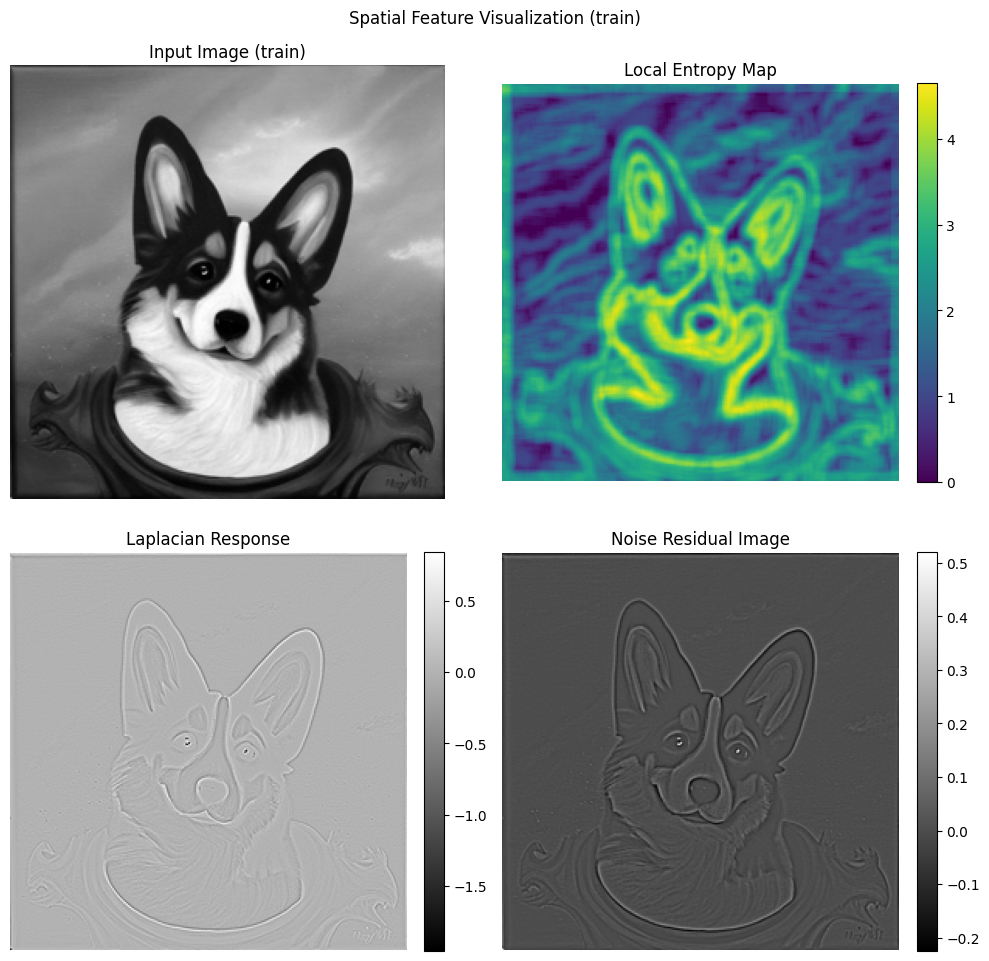

train | Sample: ai_diff_002852.png
Patch Variance Mean: 0.019654
Patch Variance Std : 0.031029


In [9]:
# ============================================
# Cell 7: Display Spatial Visualization Results
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title(f"Input Image ({SPLIT_NAME})")
axes[0, 0].axis("off")

im1 = axes[0, 1].imshow(local_entropy_map, cmap="viridis")
axes[0, 1].set_title("Local Entropy Map")
axes[0, 1].axis("off")
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)

im2 = axes[1, 0].imshow(lap, cmap="gray")
axes[1, 0].set_title("Laplacian Response")
axes[1, 0].axis("off")
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)

im3 = axes[1, 1].imshow(residual, cmap="gray")
axes[1, 1].set_title("Noise Residual Image")
axes[1, 1].axis("off")
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.suptitle(f"Spatial Feature Visualization ({SPLIT_NAME})", fontsize=12)
plt.tight_layout()
plt.show()

print(f"{SPLIT_NAME} | Sample: {SAMPLE_FILENAME}")
print(f"Patch Variance Mean: {patch_var_mean:.6f}")
print(f"Patch Variance Std : {patch_var_std:.6f}")



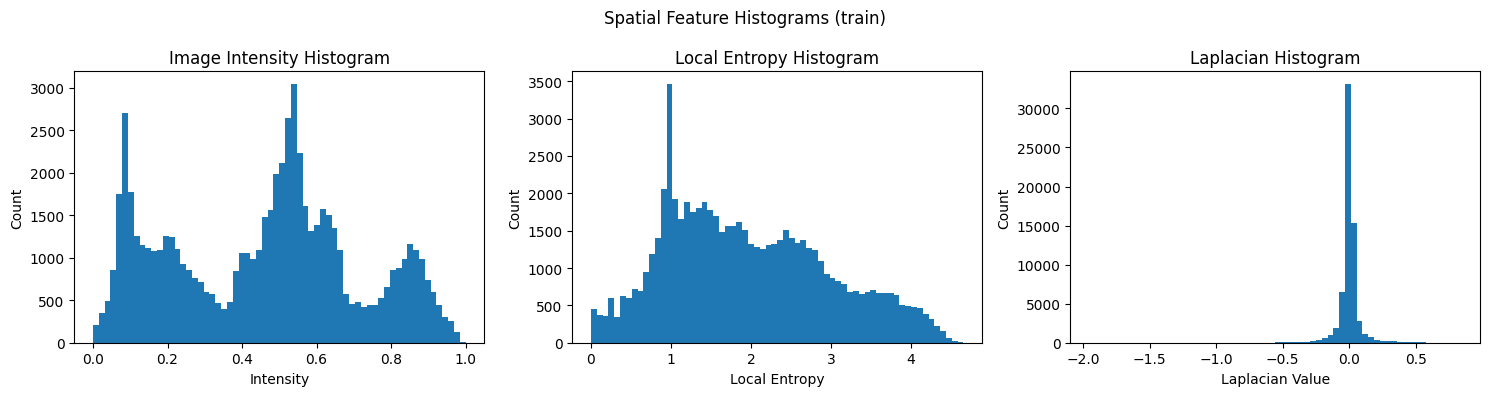

In [10]:
# ============================================
# Cell 8: Plot Spatial Histograms
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(img.ravel(), bins=64, range=(0.0, 1.0))
axes[0].set_title("Image Intensity Histogram")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Count")

axes[1].hist(local_entropy_map.ravel(), bins=64)
axes[1].set_title("Local Entropy Histogram")
axes[1].set_xlabel("Local Entropy")
axes[1].set_ylabel("Count")

axes[2].hist(lap.ravel(), bins=64)
axes[2].set_title("Laplacian Histogram")
axes[2].set_xlabel("Laplacian Value")
axes[2].set_ylabel("Count")

plt.suptitle(f"Spatial Feature Histograms ({SPLIT_NAME})", fontsize=12)
plt.tight_layout()
plt.show()



In [11]:
# ============================================
# Cell 9: Print Spatial Feature Values
# ============================================

print(f"Spatial Feature Values ({SPLIT_NAME})")
print(f"Sample Image: {SAMPLE_FILENAME}\n")

for k, v in features.items():
    print(f"{k:25s}: {v:.6f}")



Spatial Feature Values (train)
Sample Image: ai_diff_002852.png

Global Entropy           : 7.732767
Local Entropy Mean       : 1.956565
Local Entropy Std        : 1.019835
Intensity Mean           : 0.458152
Intensity Std            : 0.254423
Laplacian Variance       : 0.007067
Patch Variance Mean      : 0.019654
Patch Variance Std       : 0.031029
Noise Residual Energy    : 0.000714


Selected images from train split:
          filename class_label     source_dataset
rl_imgn_000461.png        real    ImageNet_1K_256
rl_coco_002154.png        real       MS_COCO_2017
ai_sdxl_001874.png          ai SDXL_Generated_10K
ai_diff_002961.png          ai        DiffusionDB

Class counts:
class_label
real    2
ai      2

Total selected: 4

TRAIN | Image 1 of 4
Filename: rl_imgn_000461.png
Label: real | Source: ImageNet_1K_256
Global Entropy           : 7.594439
Local Entropy Mean       : 3.100966
Local Entropy Std        : 1.218022
Intensity Mean           : 0.329209
Intensity Std            : 0.269699
Laplacian Variance       : 0.126335
Patch Variance Mean      : 0.039569
Patch Variance Std       : 0.034021
Noise Residual Energy    : 0.009098


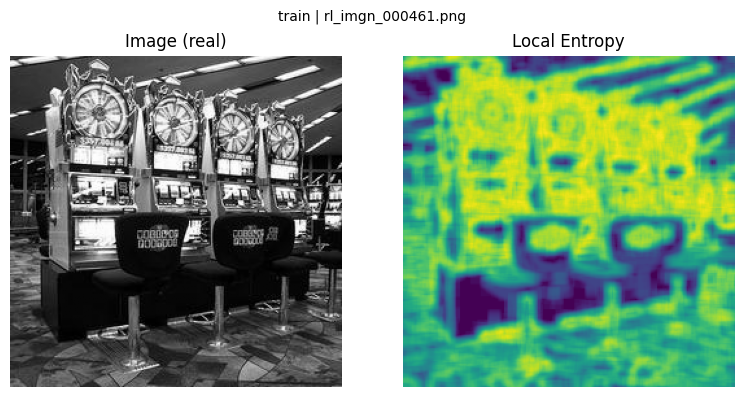


TRAIN | Image 2 of 4
Filename: rl_coco_002154.png
Label: real | Source: MS_COCO_2017
Global Entropy           : 7.557641
Local Entropy Mean       : 1.546995
Local Entropy Std        : 0.951407
Intensity Mean           : 0.478803
Intensity Std            : 0.222886
Laplacian Variance       : 0.007335
Patch Variance Mean      : 0.010209
Patch Variance Std       : 0.015961
Noise Residual Energy    : 0.000705


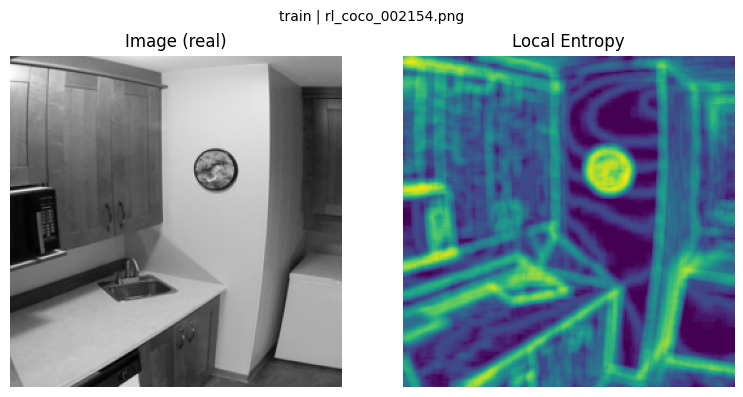


TRAIN | Image 3 of 4
Filename: ai_sdxl_001874.png
Label: ai | Source: SDXL_Generated_10K
Global Entropy           : 7.587463
Local Entropy Mean       : 2.486176
Local Entropy Std        : 0.864533
Intensity Mean           : 0.421804
Intensity Std            : 0.199717
Laplacian Variance       : 0.003215
Patch Variance Mean      : 0.012972
Patch Variance Std       : 0.014421
Noise Residual Energy    : 0.000390


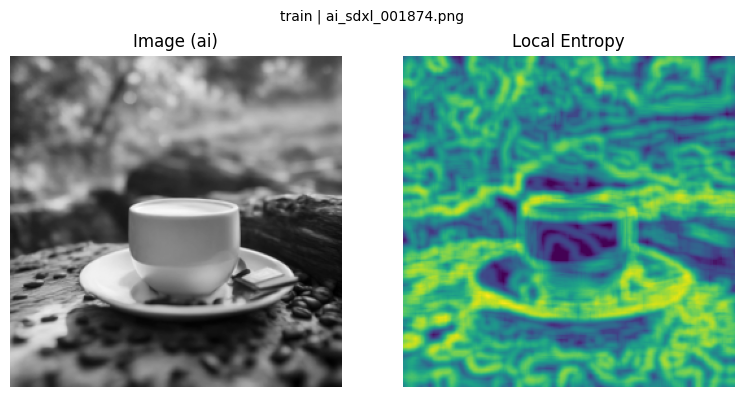


TRAIN | Image 4 of 4
Filename: ai_diff_002961.png
Label: ai | Source: DiffusionDB
Global Entropy           : 7.705085
Local Entropy Mean       : 3.127290
Local Entropy Std        : 0.881533
Intensity Mean           : 0.488051
Intensity Std            : 0.284027
Laplacian Variance       : 0.029788
Patch Variance Mean      : 0.041153
Patch Variance Std       : 0.031742
Noise Residual Energy    : 0.003153


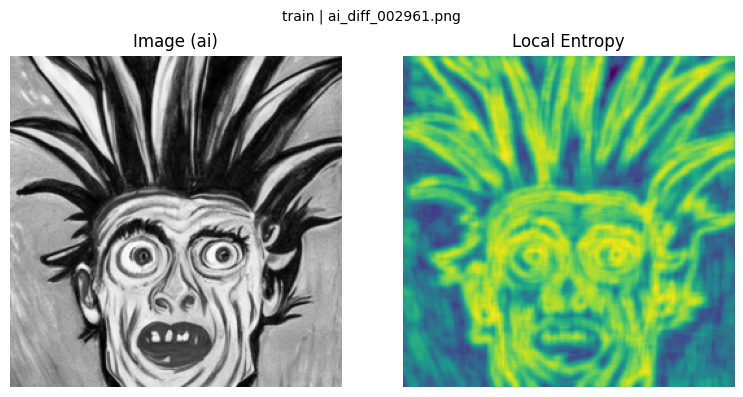

In [12]:
# ============================================
# Cell 10: Compare Real vs AI Images
# ============================================

# Select 2 real and 2 AI images (safe sampling)
df_real = df[df["class_label"] == "real"].sample(
    n=min(2, len(df[df["class_label"] == "real"])),
    random_state=42
)
df_ai = df[df["class_label"] == "ai"].sample(
    n=min(2, len(df[df["class_label"] == "ai"])),
    random_state=42
)

sample_df = pd.concat([df_real, df_ai], axis=0).reset_index(drop=True)

print(f"Selected images from {SPLIT_NAME} split:")
print(sample_df[["filename", "class_label", "source_dataset"]].to_string(index=False))
print("\nClass counts:")
print(sample_df["class_label"].value_counts().to_string())
print("\nTotal selected:", len(sample_df))

for i, row in sample_df.iterrows():
    fname = row["filename"]
    label = row["class_label"]
    source = row["source_dataset"]

    image_path = os.path.join(IMG_DIR, fname)

    img_sample = load_preprocessed_image(image_path)
    features_sample, local_entropy_map_s, lap_s, residual_s = extract_spatial_features(img_sample)

    patch_mean_s, patch_std_s = patch_variance_stats(img_sample)

    print("\n============================================")
    print(f"{SPLIT_NAME.upper()} | Image {i+1} of {len(sample_df)}")
    print(f"Filename: {fname}")
    print(f"Label: {label} | Source: {source}")

    for k, v in features_sample.items():
        print(f"{k:25s}: {v:.6f}")

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img_sample, cmap="gray")
    plt.title(f"Image ({label})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(local_entropy_map_s, cmap="viridis")
    plt.title("Local Entropy")
    plt.axis("off")

    plt.suptitle(f"{SPLIT_NAME} | {fname}", fontsize=10)
    plt.tight_layout()
    plt.show()



In [13]:
# ============================================
# Cell 11: Batch Spatial Feature Extraction
# ============================================

rows = []

for _, row in df.iterrows():
    fname = row["filename"]
    image_path = os.path.join(IMG_DIR, fname)

    try:
        img_batch = load_preprocessed_image(image_path)

        features_batch, _, _, _ = extract_spatial_features(img_batch)

        out_row = row.to_dict()
        out_row.update(features_batch)

        rows.append(out_row)

    except Exception as e:
        print(f"Skipping {fname}: {e}")

# Create DataFrame
features_df = pd.DataFrame(rows)

# Save to CSV
features_df.to_csv(OUTPUT_CSV, index=False)

print(f"Saved: {OUTPUT_CSV}")
print("Shape:", features_df.shape)
print(f"Processed split: {SPLIT_NAME}")



Saved: /content/train_spatial_features.csv
Shape: (8400, 14)
Processed split: train
